[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/diogoflim/Estatistica/blob/main/02_dist_discretas.ipynb)

In [1]:
# Célula de código
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import bernoulli, binom, poisson, randint, hypergeom

## Espaço Amostral

Vamos definir o espaço amostral S para 3 lançamentos de uma moeda justa.

A variável aleatória $X$ representa número de caras.

In [2]:
# Espaço amostral
S = ['HHH', 'HHT', 'HTH', 'HTT', 'THH', 'THT', 'TTH', 'TTT']

# Valores de X para cada resultado
X_vals = [s.count('H') for s in S]

In [3]:
X_vals

[3, 2, 2, 1, 2, 1, 1, 0]

In [4]:
# Calculando a PMF empiricamente
valores_possiveis = sorted(set(X_vals))

valores_possiveis

[0, 1, 2, 3]

In [8]:
pmf_emp = {x: X_vals.count(x)/len(S) for x in valores_possiveis}

print("PMF empírica:")
for x, p in pmf_emp.items():
    print(f"P(X={x}) = {p}")

PMF empírica:
P(X=0) = 0.125
P(X=1) = 0.375
P(X=2) = 0.375
P(X=3) = 0.125


A CDF é definida como:

$F_X(x) = P(X ≤ x)$

Vamos calculá-la a partir da PMF.


CDF empírica:
F(0) = 0.125
F(1) = 0.5
F(2) = 0.875
F(3) = 1.0


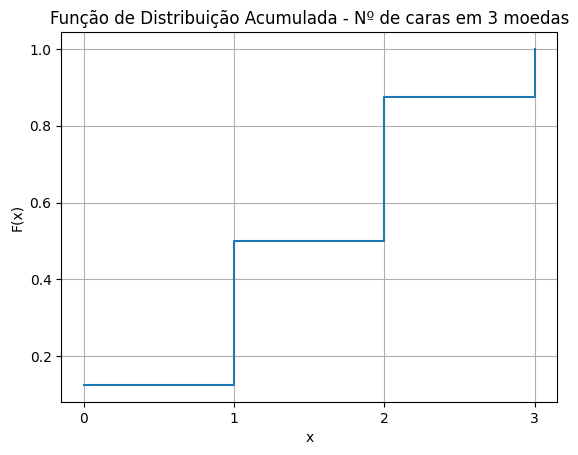

In [9]:
# Calculando a CDF

cdf_vals = {}
acc = 0

for x in sorted(pmf_emp.keys()):
    acc += pmf_emp[x]
    cdf_vals[x] = acc

print("CDF empírica:")
for x, f in cdf_vals.items():
    print(f"F({x}) = {f}")

# Plot
plt.step(list(cdf_vals.keys()), list(cdf_vals.values()), where='post')
plt.title('Função de Distribuição Acumulada - Nº de caras em 3 moedas')
plt.xlabel('x')
plt.ylabel('F(x)')
plt.xticks(range(0,4))
plt.grid(True)
plt.show()

# Distribuição de Bernoulli


Um ensaio de Bernoulli modela uma única tentativa com dois resultados: sucesso (1) e fracasso (0).

Parâmetro: π = probabilidade de sucesso.

In [10]:
pi = 0.3  # ex: 30% de sucesso

rv_bern = bernoulli(pi)

# PMF
print(f"P(X=1) = {rv_bern.pmf(1):.4f}")
print(f"P(X=0) = {rv_bern.pmf(0):.4f}")

# Esperança e variância
print(f"E[X] = {rv_bern.mean():.4f} (teórico: {pi})")
print(f"Var(X) = {rv_bern.var():.4f} (teórico: {pi*(1-pi):.4f})")

P(X=1) = 0.3000
P(X=0) = 0.7000
E[X] = 0.3000 (teórico: 0.3)
Var(X) = 0.2100 (teórico: 0.2100)


# Distribuição Binomial

Binomial: número de sucessos em n ensaios de Bernoulli independentes.


Exemplo 1: 4 ensaios, π = 0.3 é a probabilidade de sucesso (ser da classe A). Qual a probabilidade de exatamente 2 serem classe A?

In [44]:
# Célula de código
n = 4
pi = 0.3

rv_binom = binom(n, pi)

# Probabilidade exata
prob_2 = rv_binom.pmf(2)
print(f"P(X=2) = {prob_2:.4f}")

# Comparação com fórmula manual
from math import comb
manual = comb(4,2) * (pi**2) * ((1-pi)**2)
print(f"Verificação manual: {manual:.4f}")

P(X=2) = 0.2646
Verificação manual: 0.2646


In [45]:
# Exemplo 2: 12 carros, π = 0.1 de demora. Probabilidade de exatamente 2 demorarem.

n = 12
pi = 0.1
rv_binom2 = binom(n, pi)
print(f"P(X=2) = {rv_binom2.pmf(2):.4f}")

P(X=2) = 0.2301


In [46]:
# 4 pacientes, π = 0.2 (não tem plano). Vamos calcular toda a PMF e CDF.

n = 4
pi = 0.2
rv_binom3 = binom(n, pi)

x_vals = np.arange(0, n+1)

pmf_vals = rv_binom3.pmf(x_vals)
cdf_vals = rv_binom3.cdf(x_vals)

In [47]:
# Tabela
tabela = pd.DataFrame({'x': x_vals, 'PMF': pmf_vals, 'CDF': cdf_vals})
print(tabela)

   x     PMF     CDF
0  0  0.4096  0.4096
1  1  0.4096  0.8192
2  2  0.1536  0.9728
3  3  0.0256  0.9984
4  4  0.0016  1.0000


In [48]:
# Probabilidade de pelo menos 2 sem plano

prob_ge2 = 1 - rv_binom3.cdf(1)

print(f"P(X ≥ 2) = {prob_ge2:.4f}")

P(X ≥ 2) = 0.1808


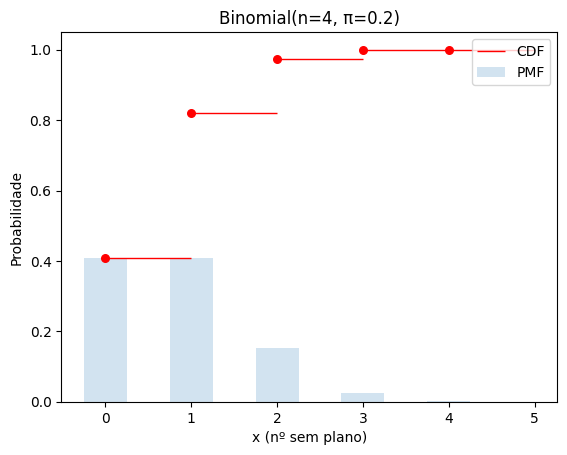

In [51]:
# Visualização
plt.bar(x_vals, pmf_vals, alpha=0.2, width=0.5, label='PMF')
plt.hlines(y=cdf_vals, xmin=x_vals, xmax=[x+1 for x in x_vals], colors='red', label='CDF', linewidth=1)
plt.scatter(x_vals, cdf_vals, color='red', marker='o', s=30)

plt.xlabel('x (nº sem plano)')
plt.ylabel('Probabilidade')
plt.title('Binomial(n=4, π=0.2)')
plt.legend(loc='upper left')
plt.show()

# Distribuição de Poisson

In [66]:
lambda_ = 1.7
rv_pois = poisson(lambda_)

x_vals = np.arange(0, 10)
pmf_pois = rv_pois.pmf(x_vals)

print("Poisson(λ=1.7):")
tabela = pd.DataFrame({'x': x_vals, 'PMF': rv_pois.pmf(x_vals), 'CDF': rv_pois.cdf(x_vals)})
print(tabela)

#Valor esperado e variância

print(f"\nE[X] = {rv_pois.mean():.4f} (λ = {lambda_})")
print(f"Var(X) = {rv_pois.var():.4f} (λ = {lambda_})")


Poisson(λ=1.7):
   x       PMF       CDF
0  0  0.182684  0.182684
1  1  0.310562  0.493246
2  2  0.263978  0.757223
3  3  0.149587  0.906811
4  4  0.063575  0.970385
5  5  0.021615  0.992001
6  6  0.006124  0.998125
7  7  0.001487  0.999612
8  8  0.000316  0.999928
9  9  0.000060  0.999988

E[X] = 1.7000 (λ = 1.7)
Var(X) = 1.7000 (λ = 1.7)


In [54]:
# Probabilidade de ≤ 2 clientes
prob_le2 = rv_pois.cdf(2)
print(f"P(X ≤ 2) = {prob_le2:.4f}")

# Probabilidade de ≥ 3 clientes
prob_ge3 = 1 - rv_pois.cdf(2)
print(f"P(X ≥ 3) = {prob_ge3:.4f}")

P(X ≤ 2) = 0.7572
P(X ≥ 3) = 0.2428


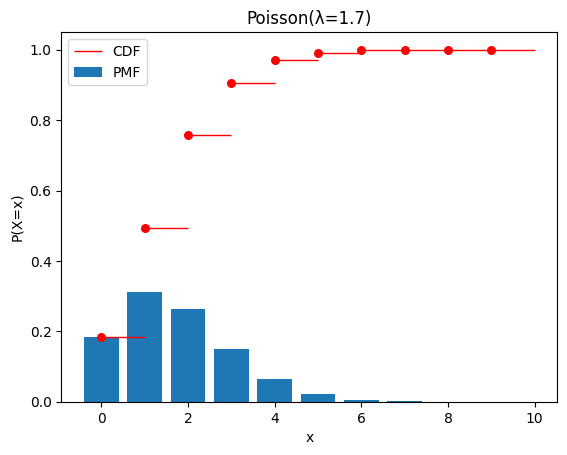

In [67]:
# Plot
plt.bar(x_vals, rv_pois.pmf(x_vals), label='PMF')

plt.hlines(y=rv_pois.cdf(x_vals), xmin=x_vals, xmax=[x+1 for x in x_vals], colors='red', label='CDF', linewidth=1)

plt.scatter(x_vals, rv_pois.cdf(x_vals), color='red', marker='o', s=30)

plt.title('Poisson(λ=1.7)')
plt.xlabel('x')
plt.ylabel('P(X=x)')
plt.legend(loc='upper left')
plt.show()

# Distribuição Uniforme Discreta

Uniforme discreta: cada valor inteiro entre a e b é igualmente provável.

In [68]:
# Exemplo: valor obtido no lançamento de um dado

a, b = 1, 6
rv_unif = randint(a, b+1)

x_vals = np.arange(a, b+1)
pmf_unif = rv_unif.pmf(x_vals)

print("PMF da Uniforme(1,6):")
tabela = pd.DataFrame({'x': x_vals, 'PMF': rv_unif.pmf(x_vals), 'CDF': rv_unif.cdf(x_vals)})
print(tabela)

print(f"E[X] = {rv_unif.mean():.4f}  (teórico: {(a+b)/2})")
print(f"Var(X) = {rv_unif.var():.4f} (teórico: {((b-a+1)**2 - 1)/12:.4f})")


PMF da Uniforme(1,6):
   x       PMF       CDF
0  1  0.166667  0.166667
1  2  0.166667  0.333333
2  3  0.166667  0.500000
3  4  0.166667  0.666667
4  5  0.166667  0.833333
5  6  0.166667  1.000000
E[X] = 3.5000  (teórico: 3.5)
Var(X) = 2.9167 (teórico: 2.9167)


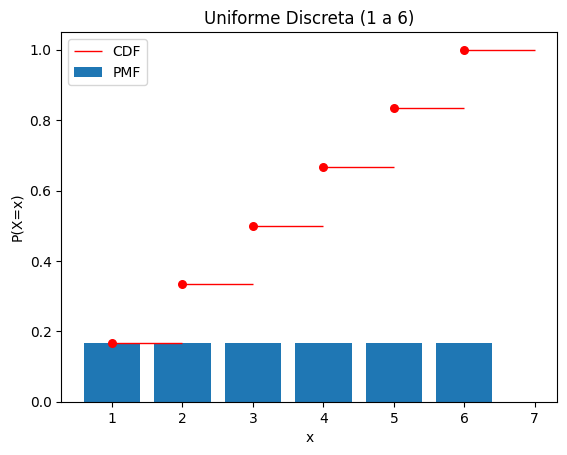

In [60]:
# Plot
plt.bar(x_vals, pmf_unif, label = 'PMF')
plt.hlines(y=rv_unif.cdf(x_vals), xmin=x_vals, xmax=[x+1 for x in x_vals], colors='red', label='CDF', linewidth=1)
plt.scatter(x_vals, rv_unif.cdf(x_vals), color='red', marker='o', s=30)
plt.title('Uniforme Discreta (1 a 6)')
plt.xlabel('x')
plt.ylabel('P(X=x)')
plt.legend(loc='upper left')
plt.show()

# Hipergeométrica: amostragem sem reposição de uma população finita.


Parâmetros: N = tamanho da população, s = número de sucessos na população, n = tamanho da amostra.

In [71]:
# Exemplo: N=10, s=4 (danificados), n=3. Probabilidade de exatamente 2 danificados na amostra.

N = 10      # população total
s = 4       # sucessos na população (danificados)
n = 3       # tamanho da amostra

rv_hyper = hypergeom(N, s, n)
x_vals = np.arange(max(0, n-(N-s)), min(s, n)+1)  # suporte possível

print("PMF da Hipergeométrica(N=10, s=4, n=3):")
tabela = pd.DataFrame({'x': x_vals, 'PMF': rv_hyper.pmf(x_vals), 'CDF': rv_hyper.cdf(x_vals)})
tabela

PMF da Hipergeométrica(N=10, s=4, n=3):


,x,PMF,CDF
0,0,0.166667,0.166667
1,1,0.500000,0.666667
2,2,0.300000,0.966667
3,3,0.033333,1.000000


In [62]:
# Probabilidade exata para x=2
prob_2 = rv_hyper.pmf(2)
print(f"\nP(X=2) = {prob_2:.4f}")


P(X=2) = 0.3000


In [72]:
# Média e variância (fórmulas)
media = n * (s / N)
var = n * (s/N) * (1 - s/N) * (N - n) / (N - 1)

print(f"E[X] = {rv_hyper.mean():.4f} (teórico: {media:.4f})")
print(f"Var(X) = {rv_hyper.var():.4f} (teórico: {var:.4f})")


E[X] = 1.2000 (teórico: 1.2000)
Var(X) = 0.5600 (teórico: 0.5600)


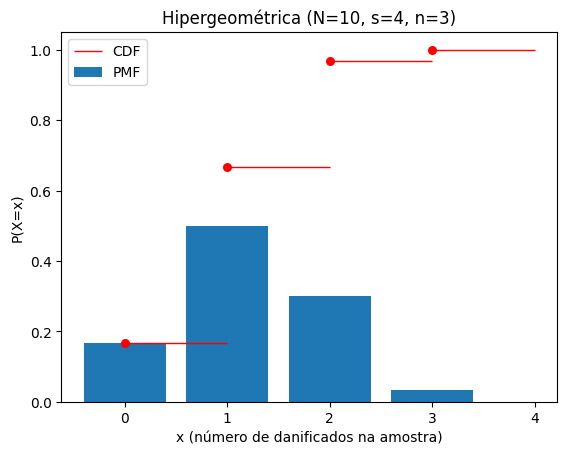

In [64]:
# Plot
plt.bar(x_vals, pmf_hyper, label='PMF')
plt.hlines(y=rv_hyper.cdf(x_vals), xmin=x_vals, xmax=[x+1 for x in x_vals], colors='red', label='CDF', linewidth=1)
plt.scatter(x_vals, rv_hyper.cdf(x_vals), color='red', marker='o', s=30)
plt.title('Hipergeométrica (N=10, s=4, n=3)')
plt.xlabel('x (número de danificados na amostra)')
plt.ylabel('P(X=x)')
plt.legend(loc= 'upper left')
plt.show()